# Classification Models Comparison - HDB Town Prediction

A clean, end-to-end notebook to prepare data, train multiple classifiers, and compare results consistently.

**Objective:** Predict `town` using structured HDB resale features and compare model accuracy, runtime, and feature importance.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [1]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
from pathlib import Path

# Auto-detect dataset path to avoid path-related runtime failures
candidate_paths = [
    Path('data.csv'),
    Path('../data.csv')
]

DATA_PATH = next((str(p) for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data.csv")
# =================================

df = pd.read_csv(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Using dataset: data.csv
Towns found: 26

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [4]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (270619, 76)
Number of features: 76


Missing values per column:
Mall_Nearest_Distance      5210
Mall_Within_500m         168137
Mall_Within_1km           49132
Mall_Within_2km            7036
Hawker_Within_500m       177013
Hawker_Within_1km        109046
Hawker_Within_2km         52516
dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-nu

In [5]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [6]:
# ========== DEFINE COLUMNS TO USE ==========
# Detect missing values in required columns and replace nulls with 0

COLUMNS_TO_USE = [
    'max_floor_lvl',
    'mid_storey',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
    '1room_sold',
    '2room_sold',
    '3room_sold',
    '4room_sold',
    '5room_sold',
    'exec_sold',
    'Mall_Within_500m',
    'Hawker_Within_500m',
    'Tranc_Year',
    # Target
    'town',
]

# ===========================================
# Validate required columns are present

missing_required_cols = [col for col in COLUMNS_TO_USE if col not in df.columns]
if missing_required_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_required_cols}")

# Diagnostic: show missing values for the columns used by the model
missing_before = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("Missing values before cleanup (columns used):")
print(missing_before.to_string())
print(f"\nTotal missing values before cleanup (columns used): {int(missing_before.sum())}")

# Replace null values with 0 in required columns
rows_before = len(df)
df[COLUMNS_TO_USE] = df[COLUMNS_TO_USE].fillna(0)
rows_after = len(df)
rows_changed = rows_before - rows_after

missing_after = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)

print("\nMissing values after cleanup (columns used):")
print(missing_after.to_string())
print(f"\nTotal missing values after cleanup (columns used): {int(missing_after.sum())}")

print(f"\nRows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_changed}")

Missing values before cleanup (columns used):
Hawker_Within_500m    177013
Mall_Within_500m      168137
Hawker_Within_2km      52516
max_floor_lvl              0
resale_price               0
hdb_age                    0
mid_storey                 0
floor_area_sqm             0
2room_sold                 0
1room_sold                 0
3room_sold                 0
4room_sold                 0
exec_sold                  0
5room_sold                 0
Tranc_Year                 0
town                       0

Total missing values before cleanup (columns used): 397666

Missing values after cleanup (columns used):
max_floor_lvl         0
mid_storey            0
Hawker_Within_2km     0
floor_area_sqm        0
resale_price          0
hdb_age               0
1room_sold            0
2room_sold            0
3room_sold            0
4room_sold            0
5room_sold            0
exec_sold             0
Mall_Within_500m      0
Hawker_Within_500m    0
Tranc_Year            0
town                  0


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

In [7]:
# ========== FEATURE ENGINEERING SECTION ==========

# Add new engineered features below. Each feature is created from existing columns.

# Feature 0: distance_from_cbd using haversine from Latitude/Longitude
def haversine(lat1, lon1, lat2, lon2):
    r = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c

cbd_lat, cbd_lon = 1.2897, 103.8501

if {'Latitude', 'Longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['Latitude'], df['Longitude'], cbd_lat, cbd_lon)
elif {'latitude', 'longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['latitude'], df['longitude'], cbd_lat, cbd_lon)
elif 'cbd_distance' in df.columns:
    df['distance_from_cbd'] = df['cbd_distance']
    print("Latitude/Longitude missing; using existing cbd_distance as distance_from_cbd.")
else:
    df['distance_from_cbd'] = 0
    print("Latitude/Longitude and cbd_distance missing; distance_from_cbd filled with 0.")

# Feature 1: age_location_score = hdb_age * (distance_from_cbd / max_cbd_distance)
if {'hdb_age', 'distance_from_cbd'}.issubset(df.columns):
    max_cbd_distance = df['distance_from_cbd'].max()
    if max_cbd_distance == 0:
        df['age_location_score'] = 0
    else:
        df['age_location_score'] = df['hdb_age'] * (df['distance_from_cbd'] / max_cbd_distance)

else:
    df['age_location_score'] = 0
    print("Skipping source dependency for age_location_score; required columns missing, filled with 0.")


# Feature 2: block_total_units = sum of sold unit types
unit_cols = ['1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold']
available_unit_cols = [c for c in unit_cols if c in df.columns]
if available_unit_cols:
    df['block_total_units'] = df[available_unit_cols].sum(axis=1)
else:
    df['block_total_units'] = 0
    print("Skipping source dependency for block_total_units; required columns missing, filled with 0.")

# Feature 3: storey_ratio = mid_storey / max_floor_lvl
if {'mid_storey', 'max_floor_lvl'}.issubset(df.columns):
    mid_storey_numeric = pd.to_numeric(df['mid_storey'], errors='coerce')
    max_floor_safe = pd.to_numeric(df['max_floor_lvl'], errors='coerce').replace(0, np.nan)
    df['storey_ratio'] = (mid_storey_numeric / max_floor_safe).fillna(0)
else:
    df['storey_ratio'] = 0
    print("Skipping source dependency for storey_ratio; required columns missing, filled with 0.")

# Create price_psm directly from resale_price / floor_area_sqm
if {'resale_price', 'floor_area_sqm'}.issubset(df.columns):
    resale_price_numeric = pd.to_numeric(df['resale_price'], errors='coerce')
    floor_area_safe = pd.to_numeric(df['floor_area_sqm'], errors='coerce').replace(0, np.nan)
    df['price_psm'] = (resale_price_numeric / floor_area_safe).fillna(0)
    print("price_psm created from resale_price / floor_area_sqm.")
else:
    df['price_psm'] = 0
    print("resale_price or floor_area_sqm missing; price_psm filled with 0.")

# Feature 4: Amenity Cluster Score ----
# How many different amenity types are within close range?
df['mrt_close'] = (df['mrt_nearest_distance'] < 500).astype(int) if 'mrt_nearest_distance' in df.columns else 0
df['mall_close'] = (df['Mall_Nearest_Distance'] < 1000).astype(int) if 'Mall_Nearest_Distance' in df.columns else 0
df['hawker_close'] = (df['Hawker_Nearest_Distance'] < 500).astype(int) if 'Hawker_Nearest_Distance' in df.columns else 0
df['school_close'] = (df['pri_sch_nearest_distance'] < 500).astype(int) if 'pri_sch_nearest_distance' in df.columns else 0
df['amenity_cluster'] = df['mrt_close'] + df['mall_close'] + df['hawker_close'] + df['school_close']

if 'price_psm' in df.columns:
    r6 = df['amenity_cluster'].corr(df['price_psm'])
    print(f"\n6. amenity_cluster (count of nearby amenity types 0-4): corr w/ price_psm = {r6:.4f}")
    print(f"   Median price_psm by cluster count:")
    print(df.groupby('amenity_cluster')['price_psm'].median().to_string())
else:
    print("\n6. amenity_cluster created, but price_psm is missing so correlation output is skipped.")

# Feature 5: Block Diversity (Shannon entropy of flat type mix) ----
if available_unit_cols:
    counts_df = df[available_unit_cols].fillna(0)
    totals = counts_df.sum(axis=1).replace(0, np.nan)
    probs = counts_df.div(totals, axis=0).replace(0, np.nan)
    df['block_diversity'] = -(probs * np.log2(probs)).sum(axis=1).fillna(0)
else:
    df['block_diversity'] = 0

if 'price_psm' in df.columns:
    r10 = df['block_diversity'].corr(df['price_psm'])
    print(f"\n10. block_diversity (Shannon entropy of flat type mix): corr w/ price_psm = {r10:.4f}")

    qcut_bins = pd.qcut(df['block_diversity'], 4, duplicates='drop')
    n_bins = len(qcut_bins.cat.categories)
    label_map = ['Low mix', 'Med-Low', 'Med-High', 'High mix']
    if n_bins > 0:
        df['div_q'] = pd.qcut(
            df['block_diversity'],
            q=n_bins,
            labels=label_map[:n_bins],
            duplicates='drop'
        )
        print(f"   Median price_psm by diversity:")
        print(df.groupby('div_q')['price_psm'].median().to_string())
    else:
        print("   Diversity quantiles unavailable for current data distribution.")
else:
    print("\n10. block_diversity created, but price_psm is missing so correlation output is skipped.")

# Display the newly created columns
new_columns = ['distance_from_cbd', 'age_location_score', 'block_total_units', 'storey_ratio', 'price_psm', 'amenity_cluster', 'block_diversity']
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")

price_psm created from resale_price / floor_area_sqm.

6. amenity_cluster (count of nearby amenity types 0-4): corr w/ price_psm = 0.1676
   Median price_psm by cluster count:
amenity_cluster
0    4829.931973
1    5020.689655
2    4728.260870
3    5284.552846
4    5767.123288

10. block_diversity (Shannon entropy of flat type mix): corr w/ price_psm = 0.1372
   Median price_psm by diversity:
div_q
Low mix     4895.348837
Med-Low     5000.000000
Med-High    4984.848485
High mix    5205.479452
Engineered Features Created:
  - distance_from_cbd: min=0.69, max=19.58, mean=11.97
  - age_location_score: min=0.76, max=48.73, mean=17.49
  - block_total_units: min=0.00, max=539.00, mean=125.78
  - storey_ratio: min=0.04, max=1.50, mean=0.56
  - price_psm: min=2207.79, max=16148.94, mean=5313.80
  - amenity_cluster: min=0.00, max=4.00, mean=2.25
  - block_diversity: min=-0.00, max=1.88, mean=0.67

Dataset now has 88 columns


Target variable distribution (town):
town
SENGKANG           20854
WOODLANDS          19845
JURONG WEST        18910
TAMPINES           18790
YISHUN             18271
PUNGGOL            16968
BEDOK              15064
HOUGANG            13815
CHOA CHU KANG      12125
ANG MO KIO         11511
BUKIT BATOK        11214
BUKIT MERAH        10390
BUKIT PANJANG       9581
TOA PAYOH           8616
KALLANG/WHAMPOA     8231
PASIR RIS           7999
SEMBAWANG           7884
QUEENSTOWN          7310
GEYLANG             6940
CLEMENTI            6249
JURONG EAST         5745
SERANGOON           5066
BISHAN              4748
CENTRAL AREA        2147
MARINE PARADE       1717
BUKIT TIMAH          629
Name: count, dtype: int64


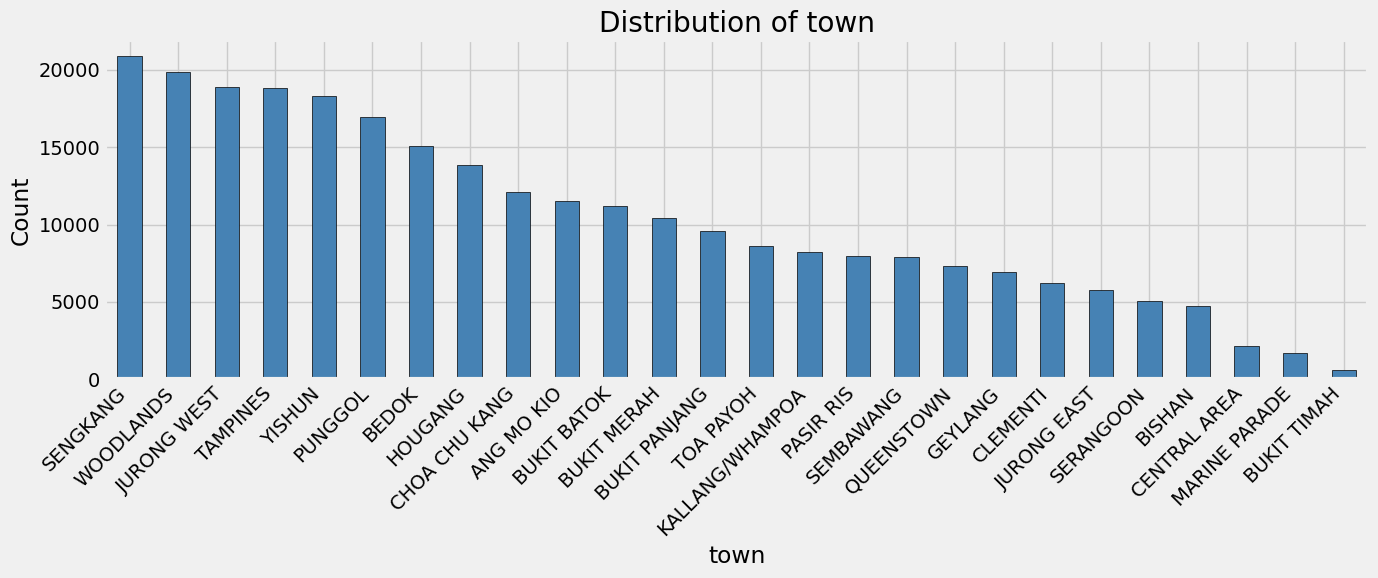

In [8]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

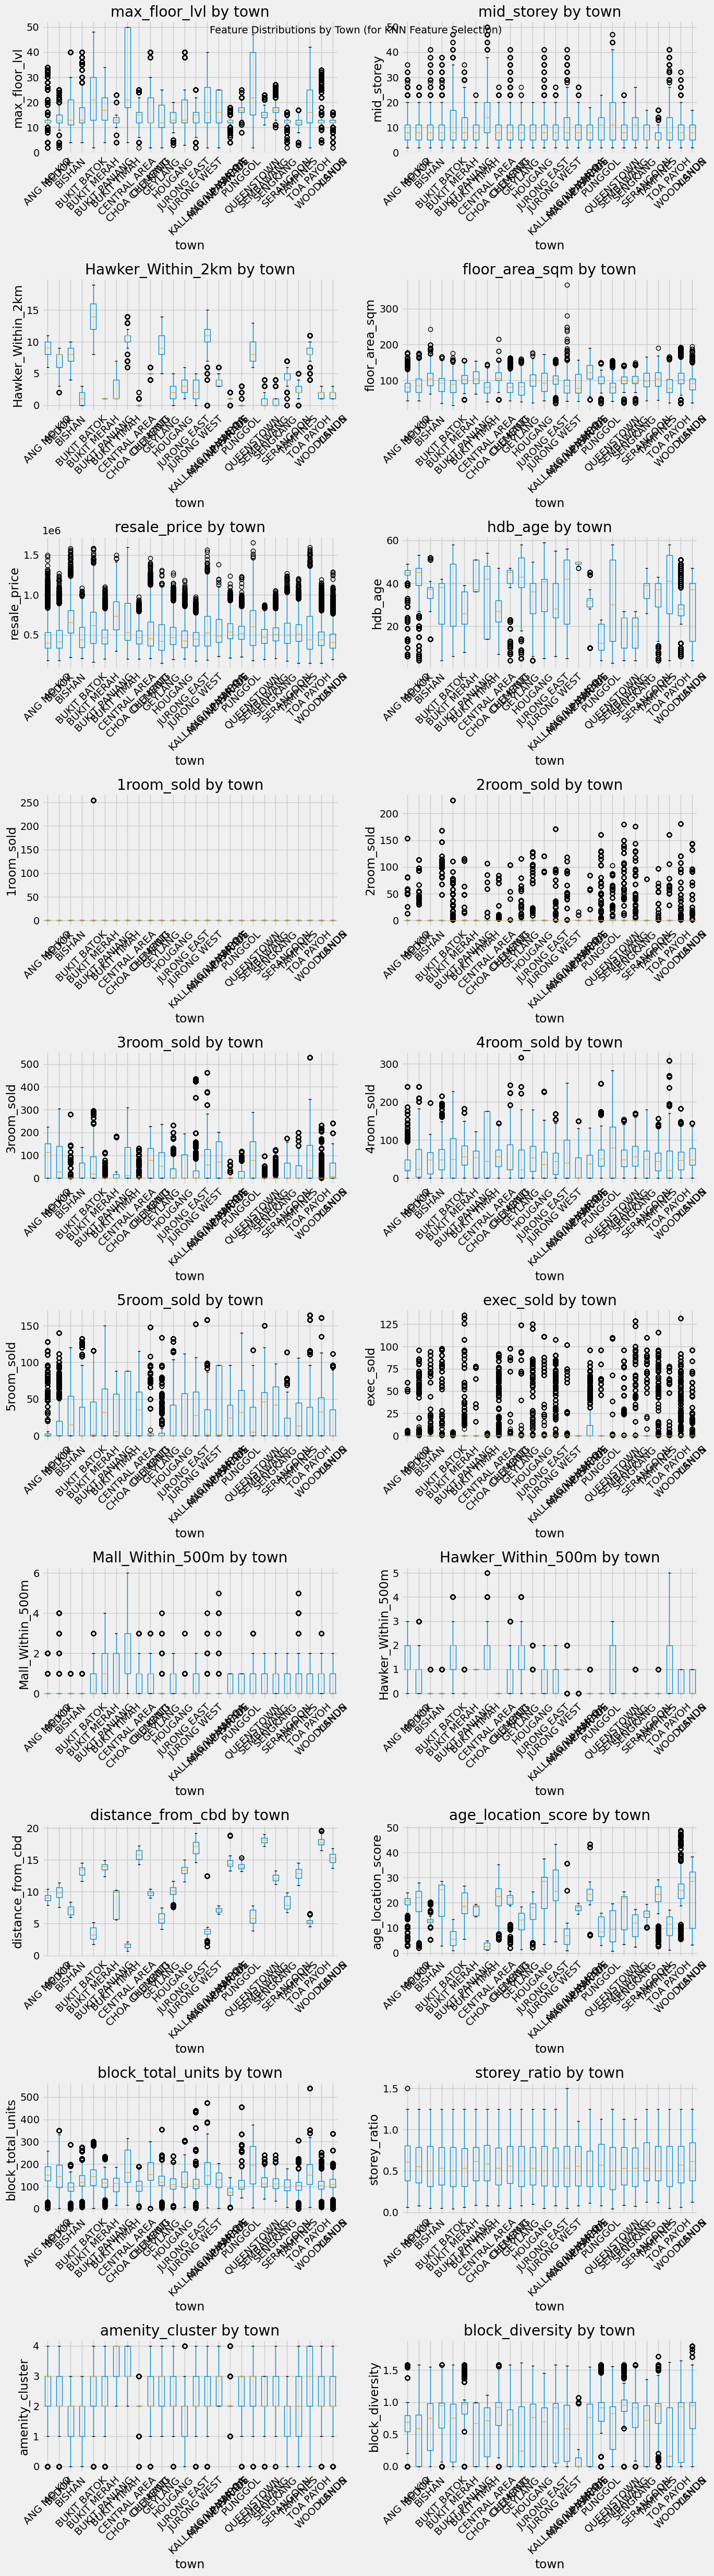

In [9]:
# ========== MODIFY THIS ==========

FEATURES_TO_PLOT = [
    'max_floor_lvl',
    'mid_storey',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
    '1room_sold',
    '2room_sold',
    '3room_sold',
    '4room_sold',
    '5room_sold',
    'exec_sold',
    'Mall_Within_500m',
    'Hawker_Within_500m',
    'distance_from_cbd',
    'age_location_score',
    'block_total_units',
    'storey_ratio',
    'amenity_cluster',
    'block_diversity'
]

# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Town (for KNN Feature Selection)', fontsize=14)
plt.tight_layout()
plt.show()


**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [10]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,14.82,8.25,9.16,84.10,462611.53,40.75,0.00,2.75,90.40,41.29,16.07,1.28,0.27,1.30,9.05,18.86,151.79,0.57,2.61,0.60
BEDOK,13.78,7.60,6.95,89.05,463109.46,40.17,0.00,2.38,78.01,47.02,18.01,3.38,0.38,0.96,9.78,20.10,148.80,0.56,2.25,0.48
BISHAN,15.72,8.20,7.83,106.72,678465.30,35.55,0.00,0.00,16.35,47.39,30.90,6.77,0.22,0.11,7.10,12.82,101.41,0.54,1.74,0.63
BUKIT BATOK,15.60,8.39,1.18,93.38,480337.53,29.88,0.00,6.41,36.35,58.08,22.14,5.83,0.13,0.15,13.28,20.12,128.80,0.56,1.68,0.75
BUKIT MERAH,21.40,11.28,13.92,86.35,613805.61,33.71,2.85,5.11,57.10,58.97,25.05,0.13,0.32,1.64,3.38,5.83,149.21,0.54,2.70,0.59
BUKIT PANJANG,18.06,9.73,1.00,102.73,486799.03,25.52,0.00,2.37,12.96,60.56,36.56,9.19,0.97,0.19,13.86,17.87,121.64,0.54,2.43,0.83
BUKIT TIMAH,12.95,7.50,2.21,108.78,753428.38,41.88,0.00,0.00,32.66,41.51,26.71,12.76,0.85,1.00,8.43,17.28,113.64,0.59,3.43,0.54
CENTRAL AREA,28.30,15.97,10.71,80.71,661806.48,34.99,0.00,5.23,71.47,75.85,30.35,0.09,2.03,1.75,1.59,2.73,183.00,0.59,3.33,0.57
CHOA CHU KANG,15.12,8.20,0.09,108.83,476704.54,25.33,0.00,1.17,7.32,53.05,36.49,7.10,0.97,0.00,15.82,20.47,105.13,0.55,2.02,0.73


In [11]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,6.60,5.57,1.49,20.38,188158.41,11.10,0.00,14.89,71.95,42.08,32.52,4.90,0.57,0.60,0.58,5.29,44.28,0.28,0.95,0.34
BEDOK,3.88,4.43,1.77,24.35,166594.02,10.48,0.00,14.20,90.84,52.45,31.85,14.22,0.97,0.73,0.97,5.86,65.53,0.29,0.93,0.41
BISHAN,7.86,6.06,1.43,24.44,212443.72,6.26,0.00,0.00,43.45,34.98,36.11,19.68,0.41,0.31,0.69,2.34,39.43,0.29,0.91,0.40
BUKIT BATOK,7.55,5.92,1.16,24.96,167934.57,13.60,0.00,26.30,40.94,48.50,35.23,20.34,0.33,0.36,0.75,9.18,50.06,0.29,0.79,0.41
BUKIT MERAH,9.68,8.04,2.37,22.63,235741.86,16.29,26.79,22.38,74.89,57.50,33.88,0.55,0.56,0.91,0.97,3.37,57.78,0.28,1.00,0.47
BUKIT PANJANG,6.39,6.24,0.00,20.36,135469.09,9.46,0.00,13.75,26.27,40.37,36.79,23.26,1.01,0.39,0.58,6.17,42.13,0.28,0.77,0.45
BUKIT TIMAH,3.33,3.96,1.89,26.32,246408.39,6.85,0.00,0.00,66.00,40.06,29.20,27.20,1.13,0.00,2.14,2.04,45.04,0.27,0.73,0.44
CENTRAL AREA,14.88,11.27,1.76,19.12,300404.87,15.09,0.00,19.26,88.89,75.01,39.17,0.46,1.33,1.02,0.39,1.26,75.84,0.27,0.56,0.39
CHOA CHU KANG,3.59,4.68,0.28,19.26,115065.03,9.98,0.00,8.68,22.11,33.75,32.42,19.21,0.73,0.00,0.79,7.83,32.77,0.28,0.69,0.43


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

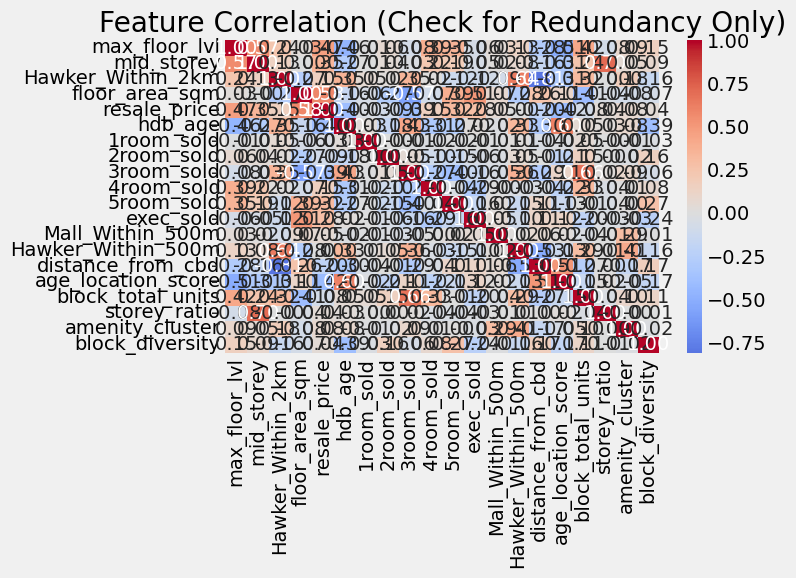


Highly correlated feature pairs (|r| > 0.8):
  Hawker_Within_2km & distance_from_cbd = -0.81


In [12]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [13]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [14]:
# ========== MODIFY THIS ==========
# Keep only leakage-safe features (no target column or target-derived column in X)

if 'df' not in globals():
    raise RuntimeError("`df` is not available. Run Step 1 to Step 3.5 first.")
if TARGET_NUMERIC_COL not in df.columns:
    raise RuntimeError("`town_num` is missing. Run Step 5a first.")

# Core features (kept from current workflow)
NUMERIC_FEATURES = [
    'max_floor_lvl',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
]

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURE_CANDIDATES = [
    'block_total_units',
    'storey_ratio',
    'amenity_cluster',
    'block_diversity',
]

ENGINEERED_FEATURES = [col for col in ENGINEERED_FEATURE_CANDIDATES if col in df.columns]
FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES
# =================================

# Verify all features exist
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

# Target leakage guard
forbidden_features = {TARGET_COLUMN, TARGET_NUMERIC_COL}
present_forbidden = [col for col in FEATURE_COLUMNS if col in forbidden_features]
if present_forbidden:
    raise ValueError(f"Target leakage detected. Remove target columns from features: {present_forbidden}")

print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
print(f"  - Numeric features: {NUMERIC_FEATURES}")
print(f"  - Engineered features: {ENGINEERED_FEATURES}")
print("Leakage guard passed: target columns are excluded from X.")

# Create feature matrix (X) and target vector (y)
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 9 features found in dataset
  - Numeric features: ['max_floor_lvl', 'Hawker_Within_2km', 'floor_area_sqm', 'resale_price', 'hdb_age']
  - Engineered features: ['block_total_units', 'storey_ratio', 'amenity_cluster', 'block_diversity']
Leakage guard passed: target columns are excluded from X.

X shape: (270619, 9)
y shape: (270619,)


In [15]:
# pd.concat([X, y], axis=1).to_csv('classification_first_permutation.csv', index=False)

### 5c. Split Data into Training and Testing Sets


In [16]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
 )

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")
print(f"Train class count: {y_train.nunique()} | Test class count: {y_test.nunique()}")
print("Leakage guard: train/test split is stratified and completed before any model fitting.")

Training set size: 202,964 rows
Testing set size:  67,655 rows
Train class count: 26 | Test class count: 26
Leakage guard: train/test split is stratified and completed before any model fitting.


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [17]:
# Scaling is intentionally performed in the next cell (Step 5d + SMOTE)
# so that StandardScaler is fit on the final training set after SMOTE.

required_split_vars = ['X_train', 'X_test', 'FEATURE_COLUMNS']
missing_split_vars = [var for var in required_split_vars if var not in globals()]
if missing_split_vars:
    raise RuntimeError(f"Missing required variables before scaling stage: {missing_split_vars}. Run Step 5b/5c first.")

print("Scaling preview cell: no scaling is executed here.")
print("Final scaling is applied in the next cell after SMOTE (training-only fit, test transform).")
print(f"Current split shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")

Scaling preview cell: no scaling is executed here.
Final scaling is applied in the next cell after SMOTE (training-only fit, test transform).
Current split shapes -> X_train: (202964, 9), X_test: (67655, 9)


In [18]:
# ========== SMOTE ON TRAINING DATA (MANDATORY) ==========
# Apply SMOTE to TRAINING data only to avoid data leakage.
# This notebook now always uses SMOTE and no longer keeps optional KNN-era toggles.
# ========================================================

_X_train_base = X_train.copy()
_y_train_base = y_train.copy()
_X_test_base = X_test.copy()
_y_test_base = y_test.copy()

# Always start from base split
X_train = _X_train_base.copy()
y_train = _y_train_base.copy()
X_test = _X_test_base.copy()
y_test = _y_test_base.copy()

# Apply SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("SMOTE applied to training data only.")

# Prepare XGBoost-safe labels once (consecutive integers from 0)
xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)

missing_test_classes = set(np.unique(y_test)) - set(xgb_label_encoder.classes_)
if missing_test_classes:
    raise ValueError(f"XGBoost label encoding issue. Classes in test but not train: {sorted(missing_test_classes)}")

y_test_xgb = xgb_label_encoder.transform(y_test)
print("XGBoost label mapping prepared in preprocessing.")

# Scale AFTER final training data is set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train rows after SMOTE: {len(y_train):,} | Test rows: {len(y_test):,}")
print("Leakage guard: scaler is fit on training data only.")

SMOTE applied to training data only.
XGBoost label mapping prepared in preprocessing.
Train rows after SMOTE: 406,640 | Test rows: 67,655
Leakage guard: scaler is fit on training data only.


---



## Step 6: Tune Logistic Regression (C)



Test different `C` values and pick the one with the lowest testing error.


In [19]:
# ========== MODIFY THIS ==========
C_VALUES = [0.01, 0.1, 1, 10, 100]
CV_FOLDS = 5
# =================================

required_vars = ['X_train_scaled', 'X_test_scaled', 'y_train', 'y_test']
missing_state = [var for var in required_vars if var not in globals()]
if missing_state:
    raise RuntimeError(f"Missing required variables: {missing_state}. Run Step 5 cells first.")

lr_search = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

param_grid = {'C': C_VALUES}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=lr_search,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
 )

search_start = time.perf_counter()
search.fit(X_train_scaled, y_train)
search_runtime = time.perf_counter() - search_start

cv_results = pd.DataFrame(search.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
cv_results = cv_results.rename(columns={'param_C': 'C', 'mean_test_score': 'cv_accuracy', 'std_test_score': 'cv_std'})
cv_results = cv_results.sort_values('cv_accuracy', ascending=False).reset_index(drop=True)

best_C = search.best_params_['C']
print(f"Best C from CV: {best_C}")
print(f"CV search runtime (sec): {search_runtime:.3f}")
display(cv_results)

Best C from CV: 100
CV search runtime (sec): 231.745


,C,cv_accuracy,cv_std
0,100.00,0.478010,0.001827
1,10.00,0.477919,0.001864
2,1.00,0.477516,0.001923
3,0.10,0.475315,0.001789
4,0.01,0.461819,0.002509


### Logistic Tuning Summary

One-line result summary is printed after selecting the best `C` from cross-validation.

In [20]:
print("Logistic Regression C tuning completed with train-only cross-validation.")
print(f"Best C selected: {best_C}")
print("No error plot generated by design (metrics-only workflow).")

Logistic Regression C tuning completed with train-only cross-validation.
Best C selected: 100
No error plot generated by design (metrics-only workflow).


---

## Step 7: Train Final Logistic Regression and Evaluate

One-line result summary is printed below with train accuracy, test accuracy, and runtime.

In [21]:
# Train final logistic regression with CV-selected C
lr_final = LogisticRegression(
    C=best_C,
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

lr_start = time.perf_counter()
lr_final.fit(X_train_scaled, y_train)
lr_runtime = time.perf_counter() - lr_start

lr_train_acc = lr_final.score(X_train_scaled, y_train)
lr_test_acc = lr_final.score(X_test_scaled, y_test)

print("Logistic Regression (final)")
print(f"Train Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy : {lr_test_acc:.4f}")
print(f"Runtime (sec) : {lr_runtime:.3f}")

Logistic Regression (final)
Train Accuracy: 0.4781
Test Accuracy : 0.3826
Runtime (sec) : 37.495


### Detailed Classification Report

In [22]:
# Logistic feature importance from absolute coefficients (multiclass average)
lr_importance = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': np.mean(np.abs(lr_final.coef_), axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(lr_importance.head(10))

,Feature,Importance
0,Hawker_Within_2km,9.773864
1,hdb_age,2.509334
2,resale_price,2.156402
3,floor_area_sqm,1.554873
4,max_floor_lvl,1.137922
5,block_total_units,0.558023
6,amenity_cluster,0.488343
7,block_diversity,0.277954
8,storey_ratio,0.153875


---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [24]:
def extract_feature_importance(model, feature_columns):
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef = model.coef_
        values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        return pd.DataFrame(columns=['Feature', 'Importance'])

    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': values
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    return importance_df

def display_aligned_table(df, format_map=None, left_cols=None, right_cols=None, hide_index=True):
    format_map = format_map or {}
    left_cols = left_cols or []
    right_cols = right_cols or []

    try:
        style = df.style
        if hide_index:
            style = style.hide(axis='index')
        if format_map:
            style = style.format(format_map)
        if left_cols:
            style = style.set_properties(subset=left_cols, **{'text-align': 'left'})
        if right_cols:
            style = style.set_properties(subset=right_cols, **{'text-align': 'right'})
        display(style)
    except Exception:
        fallback_df = df.copy()
        for col, fmt in format_map.items():
            if col in fallback_df.columns:
                fallback_df[col] = fallback_df[col].map(lambda x: fmt.format(x))
        print(fallback_df.to_string(index=not hide_index))

def evaluate_classification_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name, feature_columns):
    start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    if 'CatBoost' in type(model).__name__:
        train_pred = np.array(train_pred).astype(int).ravel()
        test_pred = np.array(test_pred).astype(int).ravel()

    train_acc = accuracy_score(y_train_data, train_pred)
    test_acc = accuracy_score(y_test_data, test_pred)
    importance_df = extract_feature_importance(model, feature_columns)

    return {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Runtime (sec)': runtime,
        'Feature Importance': importance_df,
        'fitted_model': model
    }

def print_model_result_summary(model_name, train_acc, test_acc, runtime_sec):
    print(
        f"Result summary: {model_name} achieved train accuracy {train_acc:.4f}, "
        f"test accuracy {test_acc:.4f}, and runtime {runtime_sec:.3f} seconds."
    )

print("Reusable evaluation helpers defined.")

Reusable evaluation helpers defined.


In [25]:
# Prepare shared inputs used by every model evaluation cell (Steps 9–12).

# All models are evaluated on the SAME train/test split and
# use StandardScaler-transformed features for consistency.

# X_train, X_test, y_train, y_test were created in Step 5c.
# X_train_scaled, X_test_scaled were created in Step 5d / SMOTE preprocessing.

# Class names — town labels in the same sorted order as the numeric encoding

class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()

print("Input consistency: all models use X_train_scaled / X_test_scaled.")
print("Labels: y_train / y_test (or y_train_xgb / y_test_xgb for XGBoost).")


Shared train / test split : 406640 train | 67655 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Input consistency: all models use X_train_scaled / X_test_scaled.
Labels: y_train / y_test (or y_train_xgb / y_test_xgb for XGBoost).


---

## Step 9a: Common parameters to modify


In [26]:
# MODIFY THIS CELL TO EVALUATE YOUR MODELS (Steps 9b–12)
N_ESTIMATORS = 300  # Number of trees in the forest (tune for better performance)

---

## Step 9b: Random Forest Model

One-line result summary is printed below with train accuracy, test accuracy, and runtime.

In [27]:
# ========== RANDOM FOREST ==========
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'Random Forest', FEATURE_COLUMNS
)

print("Random Forest")
print(f"Train Accuracy: {rf_results['Train Accuracy']:.4f}")
print(f"Test Accuracy : {rf_results['Test Accuracy']:.4f}")
print(f"Runtime (sec) : {rf_results['Runtime (sec)']:.3f}")
print_model_result_summary(
    "Random Forest",
    rf_results['Train Accuracy'],
    rf_results['Test Accuracy'],
    rf_results['Runtime (sec)']
)

Random Forest
Train Accuracy: 0.9997
Test Accuracy : 0.9899
Runtime (sec) : 72.118
Result summary: Random Forest achieved train accuracy 0.9997, test accuracy 0.9899, and runtime 72.118 seconds.


In [28]:
print("Top Random Forest feature importance:")
display_aligned_table(
    rf_results['Feature Importance'].head(10),
    format_map={'Importance': '{:.6f}'},
    left_cols=['Feature'],
    right_cols=['Importance']
)

Top Random Forest feature importance:


Feature,Importance
Hawker_Within_2km,0.244528
hdb_age,0.207511
max_floor_lvl,0.141781
block_total_units,0.114700
block_diversity,0.087219
floor_area_sqm,0.077989
amenity_cluster,0.063805
resale_price,0.051313
storey_ratio,0.011154


---

## Step 10: LightGBM Model

One-line result summary is printed below with train accuracy, test accuracy, and runtime.

In [29]:
# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train_scaled, X_test_scaled, y_train, y_test,
        'LightGBM', FEATURE_COLUMNS
    )
    print("LightGBM")
    print(f"Train Accuracy: {lgbm_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {lgbm_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {lgbm_results['Runtime (sec)']:.3f}")
    print_model_result_summary(
        "LightGBM",
        lgbm_results['Train Accuracy'],
        lgbm_results['Test Accuracy'],
        lgbm_results['Runtime (sec)']
    )
else:
    print("LightGBM is not installed. Run: pip install lightgbm")
    lgbm_results = None

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1847
[LightGBM] [Info] Number of data points in the train set: 406640, number of used features: 9
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097

In [30]:
if lgbm_results is not None:
    print("Top LightGBM feature importance:")
    display_aligned_table(
        lgbm_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'],
        right_cols=['Importance']
    )

Top LightGBM feature importance:


Feature,Importance
block_total_units,39165.000000
hdb_age,36334.000000
max_floor_lvl,33307.000000
block_diversity,30291.000000
Hawker_Within_2km,29631.000000
floor_area_sqm,27829.000000
resale_price,18340.000000
amenity_cluster,13030.000000
storey_ratio,6073.000000


---

## Step 11: XGBoost Model

One-line result summary is printed below with train accuracy, test accuracy, and runtime.

In [31]:
# ========== XGBOOST ==========
if XGBClassifier is not None:
    required_vars = ['y_train_xgb', 'y_test_xgb', 'xgb_label_encoder']
    missing_vars = [var for var in required_vars if var not in globals()]
    if missing_vars:
        raise RuntimeError(f"Missing XGBoost label variables: {missing_vars}. Run the SMOTE preprocessing cell first.")

    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(xgb_label_encoder.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train_scaled, X_test_scaled, y_train_xgb, y_test_xgb,
        'XGBoost', FEATURE_COLUMNS
    )
    print("XGBoost")
    print(f"Train Accuracy: {xgb_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {xgb_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {xgb_results['Runtime (sec)']:.3f}")
    print_model_result_summary(
        "XGBoost",
        xgb_results['Train Accuracy'],
        xgb_results['Test Accuracy'],
        xgb_results['Runtime (sec)']
    )
else:
    print("XGBoost is not installed. Run: pip install xgboost")
    xgb_results = None

XGBoost
Train Accuracy: 0.9364
Test Accuracy : 0.9377
Runtime (sec) : 128.485
Result summary: XGBoost achieved train accuracy 0.9364, test accuracy 0.9377, and runtime 128.485 seconds.


In [32]:
if xgb_results is not None:
    print("Top XGBoost feature importance:")
    display_aligned_table(
        xgb_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'],
        right_cols=['Importance']
    )

Top XGBoost feature importance:


Feature,Importance
Hawker_Within_2km,0.394021
hdb_age,0.192619
amenity_cluster,0.110132
max_floor_lvl,0.107743
block_total_units,0.052372
floor_area_sqm,0.047803
resale_price,0.046776
block_diversity,0.043745
storey_ratio,0.004789


---

## Step 12: CatBoost Model

One-line result summary is printed below with train accuracy, test accuracy, and runtime.

In [33]:
# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train_scaled, X_test_scaled, y_train, y_test,
        'CatBoost', FEATURE_COLUMNS
    )
    print("CatBoost")
    print(f"Train Accuracy: {catboost_results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {catboost_results['Test Accuracy']:.4f}")
    print(f"Runtime (sec) : {catboost_results['Runtime (sec)']:.3f}")
    print_model_result_summary(
        "CatBoost",
        catboost_results['Train Accuracy'],
        catboost_results['Test Accuracy'],
        catboost_results['Runtime (sec)']
    )
else:
    print("CatBoost is not installed. Run: pip install catboost")
    catboost_results = None

CatBoost
Train Accuracy: 0.8783
Test Accuracy : 0.8582
Runtime (sec) : 349.918
Result summary: CatBoost achieved train accuracy 0.8783, test accuracy 0.8582, and runtime 349.918 seconds.


In [34]:
if catboost_results is not None:
    print("Top CatBoost feature importance:")
    display_aligned_table(
        catboost_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'],
        right_cols=['Importance']
    )

Top CatBoost feature importance:


Feature,Importance
Hawker_Within_2km,37.895796
hdb_age,21.449884
max_floor_lvl,14.534168
block_total_units,7.044714
amenity_cluster,6.507026
block_diversity,5.568600
floor_area_sqm,3.648998
resale_price,3.280672
storey_ratio,0.070143


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


In [35]:
all_comparison_results = [
    {
        'Model': 'Logistic Regression',
        'Train Accuracy': lr_train_acc,
        'Test Accuracy': lr_test_acc,
        'Runtime (sec)': lr_runtime,
        'Feature Importance': lr_importance
    },
    rf_results,
    lgbm_results,
    xgb_results,
    catboost_results
]

all_comparison_results = [res for res in all_comparison_results if res is not None]

comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train Accuracy': float(r['Train Accuracy']),
        'Test Accuracy': float(r['Test Accuracy']),
        'Runtime (sec)': float(r['Runtime (sec)'])
    }
    for r in all_comparison_results
])
comparison_df['Generalization Gap'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
comparison_df['Rank'] = comparison_df['Test Accuracy'].rank(method='dense', ascending=False).astype(int)
comparison_df = comparison_df.sort_values(['Rank', 'Generalization Gap', 'Runtime (sec)']).reset_index(drop=True)

print("=" * 100)
print("MODEL COMPARISON SUMMARY")
print("=" * 100)
print("Ranking view: higher test accuracy, lower generalization gap, then lower runtime.")
print()

summary_cols = ['Rank', 'Model', 'Train Accuracy', 'Test Accuracy', 'Generalization Gap', 'Runtime (sec)']
summary_df = comparison_df[summary_cols].copy()
display_aligned_table(
    summary_df,
    format_map={
        'Rank': '{:.0f}',
        'Train Accuracy': '{:.4f}',
        'Test Accuracy': '{:.4f}',
        'Generalization Gap': '{:.4f}',
        'Runtime (sec)': '{:.3f}'
    },
    left_cols=['Model'],
    right_cols=['Rank', 'Train Accuracy', 'Test Accuracy', 'Generalization Gap', 'Runtime (sec)']
)

# Recommendation rule: if models are within 0.01 test accuracy from best, choose least runtime
ACCURACY_TOLERANCE = 0.01
best_test_accuracy = comparison_df['Test Accuracy'].max()
candidate_models = comparison_df[comparison_df['Test Accuracy'] >= (best_test_accuracy - ACCURACY_TOLERANCE)].copy()
candidate_models = candidate_models.sort_values(['Runtime (sec)', 'Generalization Gap']).reset_index(drop=True)

recommended_row = candidate_models.iloc[0]
recommended_model = recommended_row['Model']
recommended_test_acc = recommended_row['Test Accuracy']
recommended_gap = recommended_row['Generalization Gap']
recommended_runtime = recommended_row['Runtime (sec)']
recommended_candidates_count = len(candidate_models)
recommended_best_test_acc = best_test_accuracy
recommended_tolerance = ACCURACY_TOLERANCE

print("\nRecommendation rule")
print("-" * 100)
print(
    f"Models within {ACCURACY_TOLERANCE:.2f} of best test accuracy ({best_test_accuracy:.4f}) "
    f"are eligible; selected model has the lowest runtime among eligible models."
)
print("Eligible models:")

eligible_cols = ['Model', 'Test Accuracy', 'Runtime (sec)', 'Generalization Gap']
eligible_df = candidate_models[eligible_cols].copy()
display_aligned_table(
    eligible_df,
    format_map={
        'Test Accuracy': '{:.6f}',
        'Runtime (sec)': '{:.3f}',
        'Generalization Gap': '{:.6f}'
    },
    left_cols=['Model'],
    right_cols=['Test Accuracy', 'Runtime (sec)', 'Generalization Gap']
)

print("\nTop 5 Features by Model")
print("-" * 100)
for res in all_comparison_results:
    print(f"\n{res['Model']}")
    fi = res['Feature Importance']
    if fi.empty:
        print("No feature importance available.")
    else:
        display_aligned_table(
            fi.head(5),
            format_map={'Importance': '{:.6f}'},
            left_cols=['Feature'],
            right_cols=['Importance']
        )

print("\nRecommended model prepared for conclusion section.")

MODEL COMPARISON SUMMARY
Ranking view: higher test accuracy, lower generalization gap, then lower runtime.



Rank,Model,Train Accuracy,Test Accuracy,Generalization Gap,Runtime (sec)
1,Random Forest,0.9997,0.9899,0.0098,72.118
2,LightGBM,0.9828,0.9854,-0.0025,59.630
3,XGBoost,0.9364,0.9377,-0.0013,128.485
4,CatBoost,0.8783,0.8582,0.0201,349.918
5,Logistic Regression,0.4781,0.3826,0.0955,37.495



Recommendation rule
----------------------------------------------------------------------------------------------------
Models within 0.01 of best test accuracy (0.9899) are eligible; selected model has the lowest runtime among eligible models.
Eligible models:


Model,Test Accuracy,Runtime (sec),Generalization Gap
LightGBM,0.985382,59.630,-0.002534
Random Forest,0.989875,72.118,0.009795



Top 5 Features by Model
----------------------------------------------------------------------------------------------------

Logistic Regression


...


XGBoost


Feature,Importance
Hawker_Within_2km,0.394021
hdb_age,0.192619
amenity_cluster,0.110132
max_floor_lvl,0.107743
block_total_units,0.052372



CatBoost


Feature,Importance
Hawker_Within_2km,37.895796
hdb_age,21.449884
max_floor_lvl,14.534168
block_total_units,7.044714
amenity_cluster,6.507026



Recommended model prepared for conclusion section.


In [36]:
# # ========== EXPORT CLASSIFICATION MODEL AND ARTEFACTS TO WEB APP ==========
# # Run this cell after training to update app/models/ with the latest model.
# # The web app (app/app.py) reads these files at startup.
# import joblib
# import json
# from pathlib import Path

# MODEL_DIR = Path("../app/models")
# MODEL_DIR.mkdir(exist_ok=True)

# # 1. Save the best classifier (Random Forest)
# joblib.dump(rf_results["fitted_model"], MODEL_DIR / "rf_classifier.joblib")
# print("Saved: rf_classifier.joblib")

# # 2. Save the fitted scaler (used to scale features before prediction)
# joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
# print("Saved: scaler_classifier.joblib")

# # 3. Save the town class labels (index maps to town name, e.g. class 0 -> class_names[0])
# with open(MODEL_DIR / "town_classes.json", "w") as f:
#     json.dump(class_names, f, indent=2)
# print(f"Saved: town_classes.json  ({len(class_names)} towns)")
# for i, town in enumerate(class_names):
#     print(f"  {i}: {town}")

# print("
# All classification artefacts exported to app/models/")


---

## Conclusion

The recommended production candidate is selected from the comparison table using test accuracy as the primary criterion, then generalization gap, then runtime.

Run the cell above to populate the final recommendation message and supporting metrics.

In [37]:
if 'recommended_model' not in globals():
    raise RuntimeError("Run the model comparison summary cell first to generate recommendation variables.")

print("FINAL MODEL RECOMMENDATION")
print("=" * 100)
print(
    f"We will use {recommended_model} as the primary model because it is within "
    f"{recommended_tolerance:.2f} of the best test accuracy ({recommended_best_test_acc:.4f}) "
    f"and has the lowest runtime among the {recommended_candidates_count} eligible model(s)."
 )
print(
    f"Selected model metrics -> test accuracy: {recommended_test_acc:.4f}, "
    f"generalization gap: {recommended_gap:.4f}, runtime: {recommended_runtime:.3f} seconds."
 )

if recommended_gap > 0.05:
    print("Note: Generalization gap is relatively high; monitor for overfitting in production.")
else:
    print("Generalization is stable based on train-test performance gap.")

FINAL MODEL RECOMMENDATION
We will use LightGBM as the primary model because it is within 0.01 of the best test accuracy (0.9899) and has the lowest runtime among the 2 eligible model(s).
Selected model metrics -> test accuracy: 0.9854, generalization gap: -0.0025, runtime: 59.630 seconds.
Generalization is stable based on train-test performance gap.
